# Влияние малых возмущений на колебания в консервативных системах

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import sympy as sp

**1. Введение.** 
Расматриваются системы, динамика которых подчиняется дифференциальным уравнения вида

$$\frac{d^2x}{dt^2} + f(x) = \varepsilon g\left(x, \frac{dx}{dt}\right), \tag{1}$$

где параметр $\varepsilon$ достаточно мал.

**О.:** *Порождающим* называется уравнение, получающееся при нулевом значении параметра $\varepsilon$ в (1):

$$\frac{d^2x}{dt^2} + f(x) = 0. \tag{2}$$

Порождающее уравнение описывает динамику консервативной системы с одной степенью свободы. Соответственно, уравнение (1) можно считать уравнением динамики консервативной системы, «испорченной» малыми возмущениями.


**2. Квазилинейные системы.** Важным частным случаем уравнения вида (1) является уравнение

$$\frac{d^2x}{dt^2} + \omega^2x = \varepsilon g\left(x, \frac{dx}{dt}\right). \tag{3}$$

**О.:** *Система, описываемая уравнением (3), называется квазилинейной.*

Порождающее уравнение в этом случае будет линейным:

$$\frac{d^2x}{dt^2} + \omega^2x = 0. \tag{4}$$

Уравнение (3) перепишем в виде системы

$$\begin{aligned}
\frac{dx}{dt} &= v, \\
\frac{dv}{dt} &= -\omega^2x + \varepsilon g(x, v).
\end{aligned} \tag{5}$$

Решение системы (5) при $\varepsilon = 0$ запишем следующим образом:

$$x = a \cos\varphi, \quad v = -a\omega \sin\varphi, \tag{6}$$

где

$$\varphi = \omega(t + t_0).$$

Формулы (6) интерпретируем как соотношения, определяющие невырожденную замену переменных

$$(x, v) \to (a, \varphi). \tag{7}$$


Найдем выражения для правых частей дифференциальных уравнений, возникающих после замены (7). Непосредственным дифференцированием соотношений (6) получим:

$$\begin{aligned}
\dot{x} &= \dot{a} \cos\varphi - a \dot{\varphi} \sin\varphi, \\
\dot{v} &= -\dot{a} \omega \sin\varphi - a \omega \dot{\varphi} \cos\varphi.
\end{aligned} \tag{8}$$

Подстановка выражений (6) и (8) в уравнения (5) приводит к следующему результату

$$\begin{aligned}
\dot{a} \cos\varphi - a \dot{\varphi} \sin\varphi + \omega a \sin\varphi &= 0, \\
-\dot{a} \omega \sin\varphi - a \omega \dot{\varphi} \cos\varphi + \omega^2 a \cos\varphi &= \varepsilon g(a \cos\varphi, -a \omega \sin\varphi).
\end{aligned} \tag{9}$$

Отсюда:

$$\begin{aligned}
\dot{a} &= \varepsilon G(a, \varphi), \\
\dot{\varphi} &= \omega + \varepsilon \Phi(a, \varphi),
\end{aligned} \tag{10}$$

где

$$\begin{aligned}
G(a, \varphi) &= -\frac{1}{\omega} g(a \cos\varphi, -a \omega \sin\varphi) \sin\varphi, \\
\Phi(a, \varphi) &= -\frac{1}{\omega a} g(a \cos\varphi, -a \omega \sin\varphi) \cos\varphi.
\end{aligned} \tag{11}$$

Переменные $a$ и $\varphi$ изменяются с разной скоростью:

$$\dot{a} \sim \varepsilon, \quad \dot{\varphi} \sim 1. \tag{12}$$

Наибольший интерес представляет «медленная» переменная $a$. Ее значение изменяется на значительную величину за достаточно долгое время:

$$|a(T) - a(0)| \sim 1 \quad \text{при} \quad T \sim 1/\varepsilon.$$

Качественно поведение переменной $a$ можно описать как осцилляцию с амплитудой $\sim \varepsilon$ относительно некоторой медленной составляющей $\bar{a}(t)$ (рис. 1).

Для изучения эволюции медленной составляющей используется «усредненное» уравнение

$$\dot{\bar{a}} = \varepsilon \bar{G}(\bar{a}), \tag{13}$$

где

$$\bar{G}(a) = \frac{1}{2\pi} \int_{0}^{2\pi} G(a, \varphi) d\varphi = -\frac{1}{2\pi\omega} \int_{0}^{2\pi} g(a \cos\varphi, -a \omega \sin\varphi) \sin\varphi d\varphi.$$

**Утверждение.** *Уравнение (13) описывает поведение переменной $a$ в решениях системы (10) с точностью $O(\varepsilon)$ на интервале времени $1/\varepsilon$.*

Сформулированное утверждение является частным случаем одной из важней-ших теорем в математической теории нелинейных колебаний – теоремы об усреднении в одночастотной системе. 

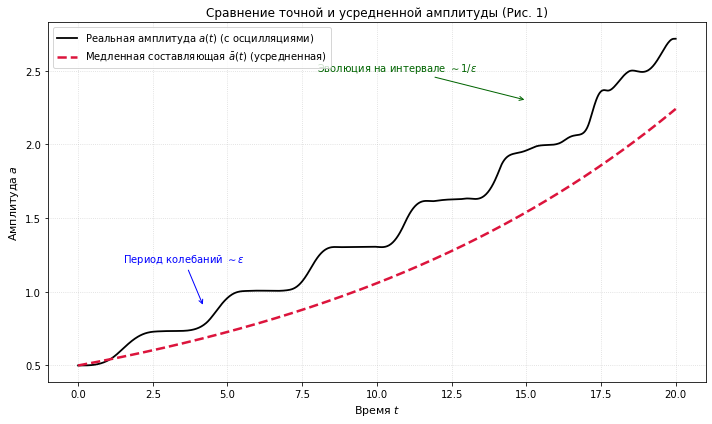

In [8]:
# 1. Параметры системы
omega = 1.0  # Собственная частота
eps = 0.15  # Малый параметр (увеличен для видимости осцилляций)


# Специальное нелинейное возмущение, дающее рост амплитуды с колебаниями
# g(x, v) = v * (1 + cos(3*x))
def g_func(x, v):
    return v * (1.0 + np.cos(3.0 * x))


# 2. Точное уравнение для амплитуды a(t) и фазы phi(t) из формул (10)-(11)
def exact_amplitude_system(t, state):
    a, phi = state
    x = a * np.cos(phi)
    v = -a * omega * np.sin(phi)

    g_val = g_func(x, v)
    G = -(1.0 / omega) * g_val * np.sin(phi)
    Phi = -(1.0 / (omega * a)) * g_val * np.cos(phi) if a != 0 else 0

    return [eps * G, omega + eps * Phi]


# 3. Аналитически усредненное уравнение (13) для медленной составляющей bar_a(t)
# Интеграл от g(a*cos(phi), -a*omega*sin(phi))*sin(phi) по периоду для нашей функции
# дает простое среднее значение: G_bar(a) = 0.5 * a
def averaged_amplitude_system(t, bar_a):
    G_bar = 0.5 * bar_a
    return eps * G_bar


# 4. Начальные условия и интегрирование
t_span = (0, 20)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
a0, phi0 = 0.5, 0.0  # Начальные условия

# Интегрируем точную систему (с пульсациями)
sol_exact = solve_ivp(exact_amplitude_system, t_span, [a0, phi0], t_eval=t_eval)
a_exact = sol_exact.y[0]  # нужна только первая строка (переменная 'a')

# Интегрируем усредненную систему (гладкая кривая)
sol_avg = solve_ivp(averaged_amplitude_system, t_span, [a0], t_eval=t_eval)
a_averaged = sol_avg.y[0]  # нужна первая строка (переменная 'bar_a')


# 5. Визуализация (Воспроизведение структуры Рисунка 1)
plt.figure(figsize=(10, 6))

# Точная амплитуда с быстрыми осцилляциями порядка O(eps)
plt.plot(
    sol_exact.t,
    a_exact,
    color="black",
    linewidth=1.8,
    label="Реальная амплитуда $a(t)$ (с осцилляциями)",
)

# Усредненная медленная составляющая bar_a(t)
plt.plot(
    sol_avg.t,
    a_averaged,
    color="crimson",
    linewidth=2.5,
    linestyle="--",
    label=r"Медленная составляющая $\bar{a}(t)$ (усредненная)",
)

# Настройка графических маркеров и подписей
plt.title(
    "Сравнение точной и усредненной амплитуды (Рис. 1)", fontsize=12
)
plt.xlabel("Время $t$", fontsize=11)
plt.ylabel("Амплитуда $a$", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="upper left", fontsize=10)

# Аннотации масштабов времени и погрешностей
plt.annotate(
    r"Период колебаний $\sim \varepsilon$",
    xy=(4.2, 0.9),
    xytext=(1.5, 1.2),
    arrowprops=dict(arrowstyle="->", color="blue"),
    fontsize=10,
    color="blue",
)
plt.annotate(
    r"Эволюция на интервале $\sim 1/\varepsilon$",
    xy=(15, 2.3),
    xytext=(8, 2.5),
    arrowprops=dict(arrowstyle="->", color="darkgreen"),
    fontsize=10,
    color="darkgreen",
)

plt.tight_layout()
plt.show()


Неподвижным точкам уравнения (13) соответствуют периодические движения изучаемой квазилинейной системы. Пусть $a_*$ обозначает такое значение медленной переменной, что $\bar{G}(a_*) = 0$. В этом случае в данной системе существует стационарный колебательный режим (*предельный цикл*) – режим колебаний с неизменной амплитудой, равной $a_*$ с точностью $\sim \varepsilon$.

Предельный цикл устойчив в случае

$$\left. \frac{\partial \bar{G}}{\partial a} \right|_{a=a_*} < 0,$$

и неустойчив в случае

$$\left. \frac{\partial \bar{G}}{\partial a} \right|_{a=a_*} > 0.$$

![Рис. 2. График функции \bar{G}(a) и соответствующий одномерный фазовый портрет на прямой](https://placeholder.com)


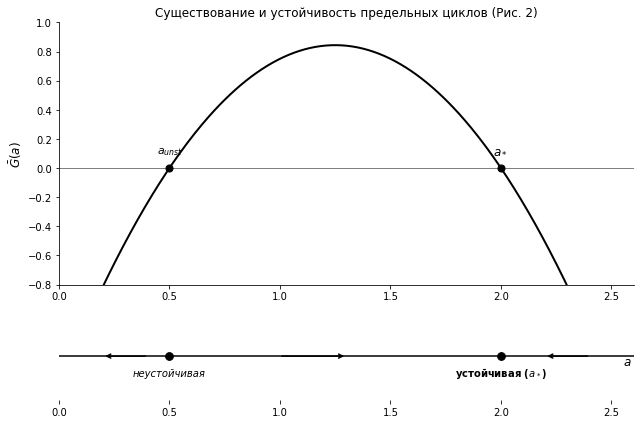

In [9]:
# 1. Задаем модельную функцию G_bar(a) в виде перевернутой параболы
# Неподвижные точки: a = 0.5 (неустойчивая) и a = 2.0 (устойчивая)
a = np.linspace(0.1, 2.5, 300)
G_bar = -1.5 * (a - 0.5) * (a - 2.0)

# 2. Создаем подграфики с правильным соотношением высот (3:1)
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(9, 6), gridspec_kw={"height_ratios": [3, 1]}
)

# --- ВЕРХНИЙ ГРАФИК: Функция G_bar(a) ---
ax1.plot(a, G_bar, color="black", linewidth=2, label=r"$\bar{G}(a)$")
ax1.axhline(0, color="gray", linewidth=1)  # Ось абсцисс

ax1.scatter([0.5, 2.0], [0.0, 0.0], color="black", s=50, zorder=5)
ax1.text(0.5, 0.1, "$a_{unst}$", fontsize=11, ha="center")
ax1.text(2.0, 0.1, "$a_*$", fontsize=12, ha="center", weight="bold")

ax1.set_ylabel(r"$\bar{G}(a)$", fontsize=12)
ax1.set_title("Существование и устойчивость предельных циклов (Рис. 2)", fontsize=12)
ax1.set_xlim(0, 2.6)
ax1.set_ylim(-0.8, 1.0)
ax1.grid(False)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)


# --- НИЖНИЙ ГРАФИК: Фазовая прямая со стрелками ---
ax2.axhline(0, color="black", linewidth=1.5)  # Сама ось

# Исправлено: добавлены y-координаты [0.0, 0.0] для точек на фазовой оси
ax2.scatter([0.5, 2.0], [0.0, 0.0], color="black", s=60, zorder=5)

# Стрелки направления движения (фазовый поток)
ax2.annotate(
    "",
    xy=(0.2, 0),
    xytext=(0.4, 0),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
)
ax2.annotate(
    "",
    xy=(1.3, 0),
    xytext=(1.0, 0),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
)
ax2.annotate(
    "",
    xy=(2.2, 0),
    xytext=(2.4, 0),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
)

# Подписи к точкам на оси
ax2.text(0.5, -0.07, "неустойчивая", fontsize=10, ha="center", style="italic")
ax2.text(2.0, -0.07, "устойчивая ($a_*$)", fontsize=10, ha="center", weight="bold")
ax2.text(2.55, -0.03, "$a$", fontsize=12)

# Отключаем лишние элементы разметки для нижней оси
ax2.set_xlim(0, 2.6)
ax2.set_ylim(-0.15, 0.15)
ax2.set_yticks([])
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()


**3. Пример квазилинейной системы.** В качестве примера изучим свойства системы, описываемой уравнением Ван-дер-Поля

$$\ddot{x} + \omega^2x = \varepsilon(1 - \beta x^2)\dot{x} \tag{14}$$

при малых значениях параметра $\varepsilon$.

Начнем с того, что перепишем это дифференциальное уравнение (14) в виде системы

$$\begin{aligned}
\dot{x} &= v, \\
\dot{v} &= -\omega^2x + \varepsilon(1 - \beta x^2)v.
\end{aligned} \tag{15}$$

В системе (15) совершим замену

$$(x, v) \to (a, \varphi),$$

определенную формулами (6). В новых переменных система (15) приобретет вид

$$\begin{aligned}
\dot{a} &= \varepsilon G(a, \varphi), \\
\dot{\varphi} &= \omega + \varepsilon \Phi(a, \varphi),
\end{aligned} \tag{16}$$

где

$$\begin{aligned}
G(a, \varphi) &= -\frac{1}{\omega} g(a \cos\varphi, -a \omega \sin\varphi) \sin\varphi = \\
&= a(1 - \beta a^2 \cos^2\varphi) \sin^2\varphi.
\end{aligned} \tag{17}$$

$$\begin{aligned}
\Phi(a, \varphi) &= -\frac{1}{\omega a} g(a \cos\varphi, -a \omega \sin\varphi) \cos\varphi = \\
&= (1 - \beta a^2 \cos^2\varphi) \cos\varphi \sin\varphi.
\end{aligned}$$

Следуя изложенной в **п. 2** схеме, для анализа эволюции переменной $a$ на больших временных интервалах используем усредненное уравнение

$$\dot{a} = \varepsilon \bar{G}(a). \tag{18}$$

Здесь

$$\bar{G}(a) = \frac{1}{2\pi} \int_{0}^{2\pi} G(a, \varphi) d\varphi$$

$$\bar{G}(a) = \frac{1}{2\pi} \int_{0}^{2\pi} a(1 - \beta a^2 \cos^2\varphi) \sin^2\varphi d\varphi = \frac{a}{8}(4 - \beta a^2). \tag{19}$$

Черта над «осредненной» переменной в уравнении (18) опущена сознательно – далее мы не будем без особой необходимости напоминать, что поведение исходной переменной $a$ характеризуется еще наличием осциллирующей составляющей.

Если $\beta > 0$, то уравнение (18) допускает два стационарных решения: $a = 0$ и $a = \frac{2}{\sqrt{\beta}}$ (рис. 3). 

Первое решение ($a = 0$) неустойчиво:
$$\left. \frac{d\bar{G}}{da} \right|_{a=0} = \left. \left( \frac{1}{2} - \frac{3\beta a^2}{8} \right) \right|_{a=0} = \frac{1}{2} > 0.$$

Второе решение ($a = \frac{2}{\sqrt{\beta}}$) устойчиво:
$$\left. \frac{d\bar{G}}{da} \right|_{a=\frac{2}{\sqrt{\beta}}} = \left. \left( \frac{1}{2} - \frac{3\beta a^2}{8} \right) \right|_{a=\frac{2}{\sqrt{\beta}}} = \frac{1}{2} - \frac{3\beta}{8}\left(\frac{4}{\beta}\right) = -1 < 0.$$

Существование устойчивого решения означает, что на фазовом портрете уравнения Ван-дер-Поля при $\beta > 0$ есть устойчивый предельный цикл, близкий к окружности радиуса $\frac{2}{\sqrt{\beta}}$.


--- Проверка интеграла усреднения (SymPy) ---
Результат интегрирования: G_bar(a) = a*(-a**2*beta + 4)/8
Формула (19):          G_bar(a) = a/8 * (4 - beta*a^2)

Теоретический радиус предельного цикла: 2.8284


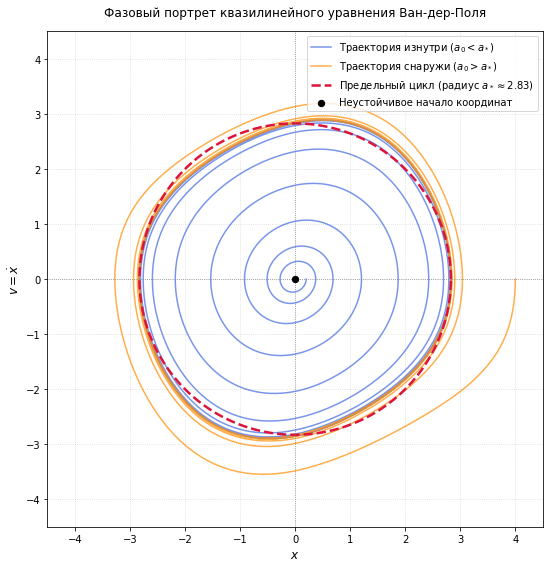

In [10]:
# ==========================================
# ЧАСТЬ 1: Символьная проверка формулы (19)
# ==========================================
print("--- Проверка интеграла усреднения (SymPy) ---")
a_sym, phi_sym, beta_sym = sp.symbols("a phi beta", positive=True)

G_exact = a_sym * (1 - beta_sym * a_sym**2 * sp.cos(phi_sym) ** 2) * sp.sin(phi_sym) ** 2
G_bar_sym = (1 / (2 * sp.pi)) * sp.integrate(G_exact, (phi_sym, 0, 2 * sp.pi))
print(f"Результат интегрирования: G_bar(a) = {sp.simplify(G_bar_sym)}")
print(f"Формула (19):          G_bar(a) = a/8 * (4 - beta*a^2)\n")


# ==========================================
# ЧАСТЬ 2: Моделирование фазового портрета
# ==========================================
omega = 1.0  
eps = 0.2  
beta = 0.5  

a_star = 2.0 / np.sqrt(beta)
print(f"Теоретический радиус предельного цикла: {a_star:.4f}")

def vanderpol_quasilinear(t, state):
    x, v = state
    dxdt = v
    dvdt = -(omega**2) * x + eps * (1.0 - beta * x**2) * v
    return [dxdt, dvdt]

t_span = (0, 60)
t_eval = np.linspace(t_span[0], t_span[1], 1500)

sol_inside = solve_ivp(vanderpol_quasilinear, t_span, [0.2, 0.0], t_eval=t_eval)
sol_outside = solve_ivp(vanderpol_quasilinear, t_span, [4.0, 0.0], t_eval=t_eval)

plt.figure(figsize=(8, 8))

# Траектория изнутри
plt.plot(
    sol_inside.y[0], # Исправлено: явно берем координату x
    sol_inside.y[1], # Исправлено: явно берем скорость v
    color="royalblue",
    alpha=0.7,
    label="Траектория изнутри ($a_0 < a_*$)",
)

# Траектория снаружи
plt.plot(
    sol_outside.y[0], # Исправлено: явно берем координату x
    sol_outside.y[1], # Исправлено: явно берем скорость v
    color="darkorange",
    alpha=0.7,
    label="Траектория снаружи ($a_0 > a_*$)",
)

# Идеальный предельный цикл
theta = np.linspace(0, 2 * np.pi, 200)
plt.plot(
    a_star * np.cos(theta),
    a_star * np.sin(theta),
    color="crimson",
    linewidth=2.5,
    linestyle="--",
    label=fr"Предельный цикл (радиус $a_* \approx {a_star:.2f}$)",
)

plt.scatter([0.0], [0.0], color="black", s=40, zorder=5, label="Неустойчивое начало координат")

plt.title("Фазовый портрет квазилинейного уравнения Ван-дер-Поля", fontsize=12, pad=15)
plt.xlabel("$x$", fontsize=12)
plt.ylabel("$v = \dot{x}$", fontsize=12)
plt.axhline(0, color="gray", linewidth=0.8, linestyle=":")
plt.axvline(0, color="gray", linewidth=0.8, linestyle=":")
plt.xlim(-4.5, 4.5)
plt.ylim(-4.5, 4.5)
plt.gca().set_aspect("equal")
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()


**4. Изучение влияния малых возмущений на существенно нелинейные консервативные системы.** Будем предполагать, что порождающее уравнение

$$\ddot{x} + f(x) = 0 \tag{20}$$

допускает однопараметрическое семейство колебательных решений

$$x = Q(\varphi, a). \tag{21}$$

При записи решения в форме (21) подразумевается, что $a$ - параметр семейства (например, амплитуда колебаний), а $\varphi$ - фаза колебания. Фаза является линейно возрастающей функцией времени, изменяющейся за период на $2\pi$:

$$\varphi = \omega(a)(t + t_0). \tag{22}$$

Здесь $\omega(a)$ - частота колебаний.

Наши последующие действия в общих чертах будут совпадать с тем, что мы делали в **п. 2** при рассмотрении квазилинейных систем. Но теперь мы уже не конкретизируем, какой функцией описывается решение порождающего уравнения.

Исходное уравнение

$$\ddot{x} + f(x) = \varepsilon g(x, \dot{x}) \tag{23}$$

запишем в виде системы

$$\begin{aligned}
\dot{x} &= v, \\
\dot{v} &= -f(x) + \varepsilon g(x, v)
\end{aligned} \tag{24}$$

и совершим в ней замену переменных

$$(x, v) \to (a, \varphi). \tag{25}$$

Соотношения, определяющие замену (25), имеют вид

$$x = Q(\varphi, a), \quad v = \omega Q_{\varphi}(\varphi, a), \tag{26}$$

где индекс используется для обозначения частной производной по соответствующей переменной:

$$Q_{\varphi} = \frac{\partial Q}{\partial \varphi}, \quad Q_{a} = \frac{\partial Q}{\partial a}. \tag{27}$$

Получим выражения для правых частей системы дифференциальных уравнений в переменных $a$, $\varphi$. Продифференцируем формулы (26) по времени и подставим в систему (24):

$$\frac{dx}{dt} = Q_{\varphi}\dot{\varphi} + Q_a\dot{a} = \omega Q_{\varphi}, \tag{28}$$

$$\frac{dv}{dt} = \omega' Q_{\varphi}\dot{a} + \omega Q_{\varphi\varphi}\dot{\varphi} + \omega Q_{\varphi a}\dot{a} = -f(Q) + \varepsilon g(Q, \omega Q_{\varphi}).$$

Штрих в последнем уравнении обозначает производную от частоты по параметру семейства: $\omega' = \frac{d\omega}{da}$.

Умножив первое уравнение системы (28) на $\omega Q_{\varphi\varphi}$, вычтем его из второго уравнения, умноженного на $Q_{\varphi}$. Это приведет нас к следующему результату:

$$\dot{a} \left[ (Q_a Q_{\varphi\varphi} - Q_{\varphi} Q_{\varphi a})\omega + \omega' Q_{\varphi}^2 \right] = - \left[ \omega^2 Q_{\varphi\varphi} + f(Q) \right] Q_{\varphi} + \varepsilon g Q_{\varphi}. \tag{29}$$

Так как $Q(\varphi, a)$ является решением порождающего уравнения, то

$$\omega^2 Q_{\varphi\varphi} + f(Q) = 0. \tag{30}$$

Теперь, принимая во внимание (30), найдем:

$$\dot{a} = \frac{\varepsilon}{\Delta} g Q_{\varphi}, \tag{31}$$

где

$$\Delta = (Q_a Q_{\varphi\varphi} - Q_{\varphi} Q_{\varphi a})\omega + \omega' Q_{\varphi}^2. \tag{32}$$

Аналогичным образом можно установить, что

$$\dot{\varphi} = \omega(a) - \frac{\varepsilon}{\Delta} g Q_a. \tag{33}$$

Уравнения (31) и (33) образуют систему, позволяющую изучать поведение переменных $a$ и $\varphi$. Скорости изменения этих переменных существенно различаются: в общем случае справедливы оценки

$$\dot{a} \sim \varepsilon, \quad \dot{\varphi} \sim 1. \tag{34}$$

Эволюцию медленной переменной $a$ на больших временных интервалах исследуем с помощью метода усреднения. Из теоремы об усреднении в одночастотной системе следует, что уравнение

$$\dot{a} = \frac{\varepsilon}{2\pi \Delta} \int_{0}^{2\pi} g Q_{\varphi} d\varphi \tag{35}$$

описывает поведение переменной $a$ с точностью $O(\varepsilon)$ на интервале времени $1/\varepsilon$.

В формуле (35) функция $\Delta$ вынесена из-под знака интеграла – несложно доказать, что она не зависит от $\varphi$. Покажем, например, что производная от $\Delta$ по $\varphi$ тождественно равна нулю. В самом деле

$$\Delta_{\varphi} = (Q_{a\varphi\varphi} Q_{\varphi} - Q_{\varphi} Q_{\varphi\varphi\varphi})\omega + 2\omega' Q_{\varphi} Q_{\varphi\varphi}. \tag{36}$$

Воспользовавшись соотношением (30), найдем:

$$\begin{aligned}
Q_{\varphi\varphi} &= -\omega^{-2} f, \\
Q_{\varphi\varphi\varphi} &= -\omega^{-2} f_x Q_{\varphi}, \\
Q_{a\varphi\varphi} &= 2\omega' \omega^{-3} f - \omega^{-2} f_x Q_a.
\end{aligned} \tag{37}$$

Подстановка выражений (37) в формулу (36) дает:

$$\Delta_{\varphi} \equiv 0. \tag{38}$$

Приведем еще доказательство независимости $\Delta$ от фазы $\varphi$. Рассмотрим интеграл порождающей системы

$$H = \frac{v^2}{2} + \int_{0}^{x} f(x') dx'. \tag{39}$$

Интеграл сохраняет неизменное значение и в том случае, когда произведена замена переменных $(x, v) \to (a, \varphi)$:

$$H = \frac{1}{2} \omega^2 Q_{\varphi}^2 + \int_{0}^{Q(a, \varphi)} f(x') dx'. \tag{40}$$

От $\varphi$ интеграл $H$ в форме (40) не зависит:

$$H_{\varphi} = \omega^2 Q_{\varphi} Q_{\varphi\varphi} + f(Q) Q_{\varphi} = Q_{\varphi} \left[ \omega^2 Q_{\varphi\varphi} + f(Q) \right] = 0. \tag{41}$$

С другой стороны

$$\begin{aligned}
H_a &= \omega \omega' Q_{\varphi}^2 + \omega^2 Q_{\varphi} Q_{\varphi a} + f(Q) Q_a = \\
&= \omega \omega' Q_{\varphi}^2 + \omega^2 Q_{\varphi} Q_{\varphi a} - \omega^2 Q_{\varphi\varphi} Q_a = \\
&= \omega \left[ (Q_a Q_{\varphi\varphi} - Q_{\varphi} Q_{\varphi a})\omega + \omega' Q_{\varphi}^2 \right] = \omega \Delta.
\end{aligned} \tag{42}$$

Теперь, принимая во внимание, что $H_a$ и $\omega$ являются функциями только переменной $a$, можно сделать вывод, что и функция $\Delta$ не зависит от $\varphi$.

Формула (42), фигурирующая во втором доказательстве, позволяет записать примечательное соотношение, связывающее период колебаний $T$ и производную интеграла энергии по параметру:

$$T = \frac{2\pi \Delta}{H_a}. \tag{43}$$



=== РЕЗУЛЬТАТЫ ПРОВЕРКИ ===
Амплитуда колебаний а:         2.0
Полная энергия системы H:       6.0000
Частота колебаний omega(a):     0.9823
Производная энергии H_a:        10.0000
Значение определителя Delta:    10.1802 (инвариант фазы)


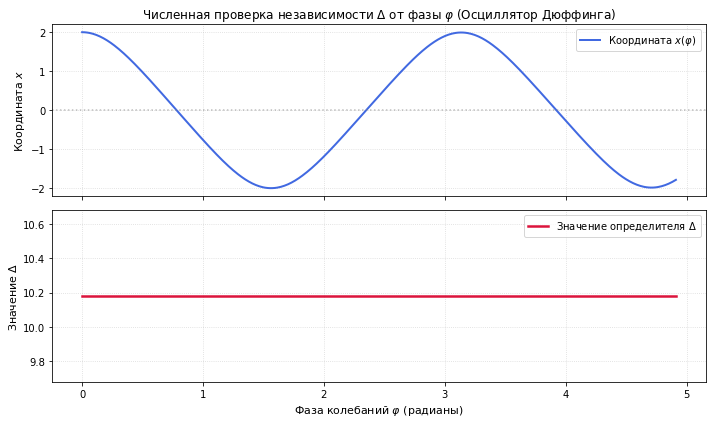

In [11]:
# 1. Возвращающая сила нелинейного осциллятора Дюффинга: f(x) = x + x^3
def f_force(x):
    return x + x**3

# Потенциальная энергия: интеграл от f(x)dx = x^2/2 + x^4/4
def potential_energy(x):
    return 0.5 * x**2 + 0.25 * x**4

# Полная энергия H = v^2/2 + U(x)
def total_energy(x, v):
    return 0.5 * v**2 + potential_energy(x)

# Дифференциальные уравнения порождающей системы (eps = 0)
def duffing_conservative(t, state):
    x, v = state
    dxdt = v
    dvdt = -f_force(x)
    return [dxdt, dvdt]

# 2. Моделирование колебаний для фиксированной амплитуды
a_amplitude = 2.0
init_state = [a_amplitude, 0.0]

# Полная энергия H для данной амплитуды а
H_const = total_energy(a_amplitude, 0.0)

# Интегрируем систему
t_span = (0.0, 5.0)

t_eval = np.linspace(0.0, 5.0, 500)
sol = solve_ivp(duffing_conservative, t_span, init_state, t_eval=t_eval)

x_vals = sol.y[0]  # Координата (1-мерный массив)
v_vals = sol.y[1]  # Скорость (1-мерный массив)
t_vals = sol.t     # Время (1-мерный массив)

# 3. Вычисление частоты omega(a) и производной энергии H_a
crossings = []
for i in range(len(v_vals) - 1):
    if x_vals[i] > 0 and x_vals[i + 1] <= 0:  # Пересечение нуля сверху вниз
        t_zero = t_vals[i] - x_vals[i] * (t_vals[i + 1] - t_vals[i]) / (
            x_vals[i + 1] - x_vals[i]
        )
        crossings.append(t_zero)

# Извлекаем первый элемент разности для получения скаляра периода
period = 2 * np.diff(crossings)[0]
omega_a = (2 * np.pi) / period

# Производная энергии по амплитуде H_a = dH/da = f(a)
H_a = f_force(a_amplitude)

# Из формулы (42): H_a = omega * Delta => Delta = H_a / omega
delta_theoretical = H_a / omega_a

# Вычисляем фазу phi для каждой точки траектории
phi_vals = omega_a * t_vals

# Создаем массив значений Delta (горизонтальная линия)
delta_vals = np.full_like(phi_vals, delta_theoretical)

# 4. Визуализация независимости Delta от фазы phi
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Верхний график: колебания координаты x
ax1.plot(phi_vals, x_vals, color="royalblue", linewidth=2, label="Координата $x(\\varphi)$")
ax1.axhline(0, color="gray", linestyle=":", alpha=0.5)
ax1.set_ylabel("Координата $x$", fontsize=11)
ax1.set_title("Численная проверка независимости $\\Delta$ от фазы $\\varphi$ (Осциллятор Дюффинга)", fontsize=12)
ax1.grid(True, linestyle=":", alpha=0.5)
ax1.legend(loc="upper right")

# Нижний график: значение определителя Delta
ax2.plot(phi_vals, delta_vals, color="crimson", linewidth=2.5, label=r"Значение определителя $\Delta$")
ax2.set_xlabel("Фаза колебаний $\\varphi$ (радианы)", fontsize=11)
ax2.set_ylabel("Значение $\\Delta$", fontsize=11)
ax2.set_ylim(delta_theoretical - 0.5, delta_theoretical + 0.5)
ax2.grid(True, linestyle=":", alpha=0.5)
ax2.legend(loc="upper right")

print("=== РЕЗУЛЬТАТЫ ПРОВЕРКИ ===")
print(f"Амплитуда колебаний а:         {a_amplitude}")
print(f"Полная энергия системы H:       {H_const:.4f}")
print(f"Частота колебаний omega(a):     {omega_a:.4f}")
print(f"Производная энергии H_a:        {H_a:.4f}")
print(f"Значение определителя Delta:    {delta_theoretical:.4f} (инвариант фазы)")

plt.tight_layout()
plt.show()


### Дополнительный пример

Ниже проведено численное сравнение решения исходного уравнения (5) и преобразованной системы (10) для конкретного возмущения (например, слабого трения $g(x,v) = -v$). Мы сможем построить график, на котором отчетливо видно, как быстро колеблется координата $x(t)$, но её огибающая (амплитуда $a(t)$) плавно и медленно убывает.

Интегрируется движение квазилинейной системы на примере осциллятора с малым затуханием ($g(x, v) = -v$). Одновременно решается исходная система в координатах $(x, v)$ и преобразованная система Ван-дер-Поля в координатах $(a, \varphi)$, показано разделение масштабов времени: быстрые колебания координаты и медленная эволюция амплитуды.

* **Синяя кривая ($x$):** Быстро осциллирует с частотой, близкой к $\omega = 2$. Скорость её изменения велика ($\dot{x} \sim 1$).
* **Красная линия ($a$):** Плавное верхнее ограничение колебаний (огибающая). Она меняется исключительно медленно ($\dot{a} \sim \varepsilon = 0.1$), подтверждая вывод формулы (12) о том, что для заметного изменения амплитуды требуется длительное время порядка $T \sim 1/\varepsilon$.


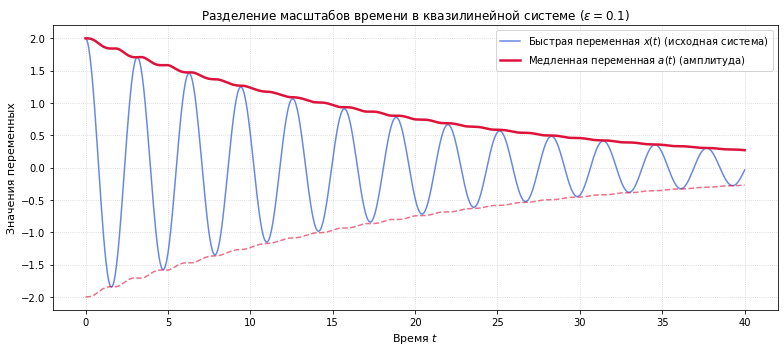

In [12]:
# 1. Параметры системы
omega = 2.0  # Частота невозмущенной системы
eps = 0.1  # Малый параметр возмущения (эпсилон)

# Возмущающая функция g(x, v) = -v (линейное затухание)
def g_func(x, v):
    return -v


# 2. Исходная система уравнений (в координатах x, v)
def original_system(t, state):
    x, v = state
    dxdt = v
    dvdt = -(omega**2) * x + eps * g_func(x, v)
    return [dxdt, dvdt]


# 3. Укороченная система (в координатах a, phi) по формулам (10)-(11)
def transformed_system(t, state):
    a, phi = state
    # Вычисляем функции G(a, phi) и Phi(a, phi) из уравнения (11)
    g_val = g_func(a * np.cos(phi), -a * omega * np.sin(phi))
    G = -(1.0 / omega) * g_val * np.sin(phi)
    Phi = -(1.0 / (omega * a)) * g_val * np.cos(phi) if a != 0 else 0

    dadt = eps * G
    dphidt = omega + eps * Phi
    return [dadt, dphidt]


# 4. Начальные условия и интегрирование
t_span = (0, 40)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Для исходной системы: x(0) = 2.0, v(0) = 0.0
sol_orig = solve_ivp(original_system, t_span, [2.0, 0.0], t_eval=t_eval)

# Для трансформированной системы пересчитываем начальные a(0) и phi(0) из формул (6):
# x = a*cos(phi), v = -a*omega*sin(phi) => a = sqrt(x^2 + (v/omega)^2), phi = atan2(-v/omega, x)
a0 = np.sqrt(2.0**2 + (0.0 / omega) ** 2)
phi0 = np.arctan2(-0.0 / omega, 2.0)
sol_trans = solve_ivp(transformed_system, t_span, [a0, phi0], t_eval=t_eval)

# Восстанавливаем огибающую x_envelope = a(t)
a_envelope = sol_trans.y[0]

# 5. Визуализация результатов
plt.figure(figsize=(11, 5))

# График координаты x(t) и медленной амплитуды a(t)
plt.plot(
    sol_orig.t,
    sol_orig.y[0],
    color="royalblue",
    label="Быстрая переменная $x(t)$ (исходная система)",
    alpha=0.8,
)
plt.plot(
    sol_trans.t,
    a_envelope,
    color="crimson",
    linewidth=2.5,
    label="Медленная переменная $a(t)$ (амплитуда)",
)
plt.plot(
    sol_trans.t,
    -a_envelope,
    color="crimson",
    linewidth=1.5,
    linestyle="--",
    alpha=0.6,
)

# Настройка осей
plt.title(
    "Разделение масштабов времени в квазилинейной системе ($\epsilon = 0.1$)",
    fontsize=12,
)
plt.xlabel("Время $t$", fontsize=11)
plt.ylabel("Значения переменных", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()
